# Week4 - Homework

- Execute the below code, then answer the numbered questions.

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge


df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/regression/car-reg-data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9055 entries, 0 to 9054
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   make           8164 non-null   object 
 1   transmission   8106 non-null   object 
 2   state          8152 non-null   object 
 3   condition      8173 non-null   float64
 4   odometer       8178 non-null   float64
 5   auction_value  8107 non-null   float64
 6   selling_price  9055 non-null   float64
dtypes: float64(4), object(3)
memory usage: 495.3+ KB


In [100]:
from sklearn.model_selection import train_test_split
features = [x for x in df.columns if x != 'selling_price']

X = df[features]
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

print(f'Records in training data: {X_train.shape[0]:,}')
print(f'Records in test data: {X_test.shape[0]:,}')
print('\nFeatures:')
print(*X_train.columns, sep='\n')

Records in training data: 7,244
Records in test data: 1,811

Features:
make
transmission
state
condition
odometer
auction_value


In [101]:
df.head()

,make,transmission,state,condition,odometer,auction_value,selling_price
0,nissan,automatic,md,4.8,NaN,14350.0,13600.0
1,ford,automatic,mo,3.7,29398.0,17600.0,17100.0
2,ford,automatic,fl,3.2,32180.0,19100.0,17600.0
3,nissan,automatic,ca,NaN,30798.0,11950.0,10700.0
4,ford,automatic,nj,2.8,29526.0,28000.0,26100.0


## Question 1: Split the features into two lists, one for the numerical features and another for the categorical features.

In [102]:
Numerical_features = []
Categorical_features = []

for column in X_train.columns:
    if X_train[column].dtype in ['int64', 'float64']:
        Numerical_features.append(column)
    else:
        Categorical_features.append(column)

print("Numerical Features:")
print(Numerical_features)

print("\nCategorical Features:")
print(Categorical_features)


Numerical Features:
['condition', 'odometer', 'auction_value']

Categorical Features:
['make', 'transmission', 'state']


## Question 2: Using the numerical variables, create a pipeline that replaces the missing values with the median and then standardizes the values using a standard scaler.

In [103]:
Numerical_features = ['condition', 'odometer', 'auction_value']
Numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler())  
])
df[Numerical_features] = Numerical_pipeline.fit_transform(df[Numerical_features])
df[Numerical_features]

,condition,odometer,auction_value
0,1.333059,-0.185336,-0.191185
1,-0.081007,-0.410985,0.249020
2,-0.723764,-0.314109,0.452192
3,0.176096,-0.362234,-0.516260
4,-1.237969,-0.406528,1.657678
...,...,...,...
9050,0.561750,-0.000498,-0.245364
9051,0.176096,-0.083236,0.066166
9052,1.204507,-1.276220,-0.441764
9053,1.075956,-0.281585,0.817901


## Question 3: Using the categorical variables, create a pipeline that replaces the missing values with the most frequent and then use one-hot encoding to convert the data to numerical arrays.
- You should be dropping one category from each variable when using the one-hot encoder.  
- To ensure the pipeline doesn't break when it receives new/unexpected categories, you should ignore new categories.
- Use a fit transformer on the training dataset to validate all the columns are now numeric and to determine how many columns the transformed data contains.

In [104]:
Categorical_features = ['make', 'transmission', 'state']
Categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')) 
])
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Categorical_transformer, Categorical_features)  
    ])
def fit_transformer(X):
    preprocessor.fit(X)
    return preprocessor.transform(X)

X_train_transform = fit_transformer(X_train)

print(f"No of columns: {X_train_transform.shape[1]}")


No of columns: 41


## Question 4: Combine the numerical and categorical pipelines into one data processing pipeline.
- Use a fit transformers and the training dataset to verify the data has no missing values and the correct number of columns.

In [105]:
Numerical_features = ['condition', 'odometer', 'auction_value']
Categorical_features = ['make', 'transmission', 'state']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Numerical_pipeline, Numerical_features),
        ('cat', Categorical_pipeline, Categorical_features)
    ])
X_train_transform = preprocessor .fit_transform(X_train)
mis_values = pd.DataFrame(X_train_transform).isnull().sum()
num_columns = X_train_transform.shape[1]
print("Missing Values:\n", mis_values)
print("\nNumber of Columns:", num_columns)

Missing Values:
 0    0
dtype: int64

Number of Columns: 44


## Question 5: Add a linear regression model to the pipeline.
- Report what the $R^2$ is using the `test` data.  

In [106]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('model', LinearRegression())  
])
final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)
r_squared = r2_score(y_test, y_pred)
print(f'R-squared (𝑅²) score on the test data: {r_squared:.4f}')

R-squared (𝑅²) score on the test data: 0.8838


## Question 6: Create a plot(s) of the residuals. Do you have any concerns about patterns in the residuals that the model is neglecting to pick-up?
- Include a sentence or two on what you observe.

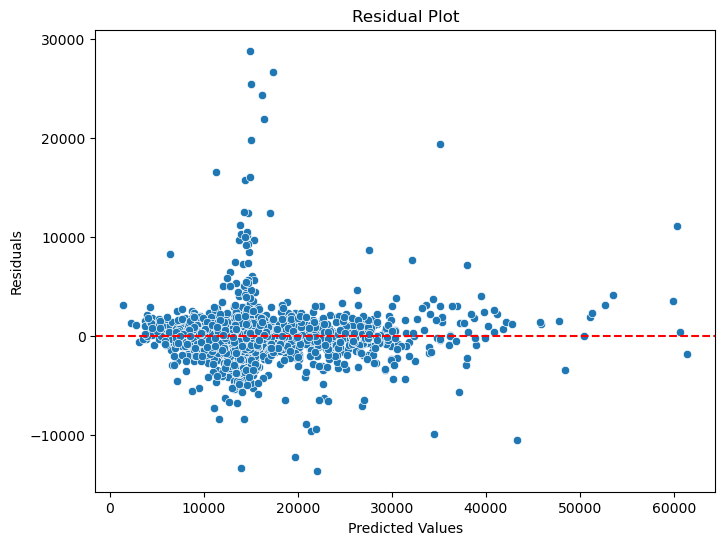

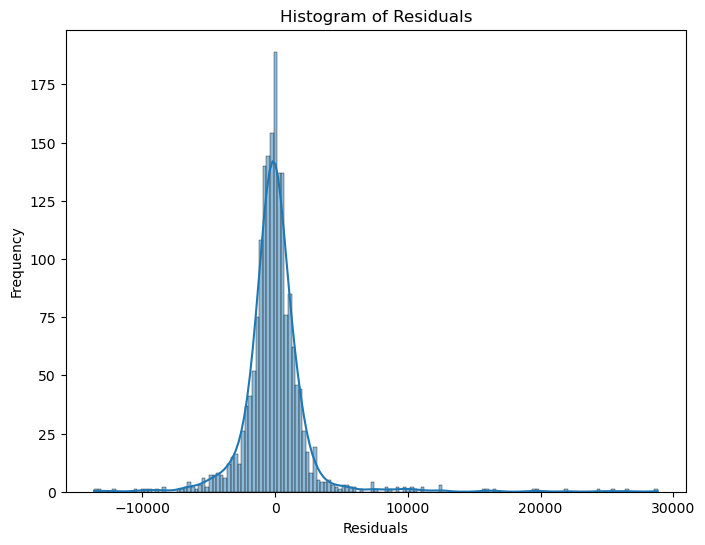

In [107]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In the first plot the residuals are around zero suggests that the model is predicting accurately but however there are fewer patterns whcih suggest that the model needs improvement. 

The second plot suggests that the residuals has more frequnecy at zero which tells us that the model is predicted accurately. It basically shows the frequency of the residual for imporoving accuracy. 

## Question 7: Modify the pipeline to use a ridge regression model with an alpha value of 100. How does this change the $R^2$?

In [108]:
model = Ridge(alpha=100)
data_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('model', model) 
])
data_pipeline.fit(X_train, y_train)
y_pred = data_pipeline.predict(X_test)
r_squared = r2_score(y_test, y_pred)
print(f'R-squared (𝑅²) score on the test data with Ridge Regression:', r_squared)

R-squared (𝑅²) score on the test data with Ridge Regression: 0.8824295262289528


There is no change actually when I tried with Ridge Regression compared to Linear Regression.